# **Automated Deployment Pipeline**

In [ ]:
import os
import zipfile

print("--- Step 1: File System Check ---")
# List all files in the current directory
all_files = os.listdir('.')
print(f"Current files in root: {all_files}")

# Automatic Unzipper
zip_files = [f for f in all_files if f.endswith('.zip')]

if zip_files:
    print(f"\nFound {len(zip_files)} zip archives. Extracting now...")
    for zf in zip_files:
        try:
            with zipfile.ZipFile(zf, 'r') as zip_ref:
                zip_ref.extractall('.')
            print(f"✅ Extracted: {zf}")
        except Exception as e:
            print(f"❌ Error extracting {zf}: {e}")
else:
    print("\nNo .zip files found in the root directory. Checking for folders...")

# Verifying if CSVs are now visible
print("\n--- Step 2: Verification Search ---")
csv_count = 0
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            csv_count += 1
            #print first 3 found CSVs to confirm
            if csv_count <= 3:
                print(f"Found CSV: {os.path.join(root, file)}")

if csv_count == 0:
    print("❌ CRITICAL: Still no CSV files found.")
    print("ACTION REQUIRED: Please look at the 'Files' folder icon on the left sidebar.")
    print("If it is empty, you must Drag & Drop your files there again.")
else:
    print(f"✅ SUCCESS: Found {csv_count} CSV files. You can proceed to the next cell.")

--- Step 1: File System Check ---
Current files in root: ['.config', 'api_data_aadhar_biometric.zip', 'api_data_aadhar_enrolment.zip', 'api_data_aadhar_demographic.zip', 'sample_data']

Found 3 zip archives. Extracting now...
✅ Extracted: api_data_aadhar_biometric.zip
✅ Extracted: api_data_aadhar_enrolment.zip
✅ Extracted: api_data_aadhar_demographic.zip

--- Step 2: Verification Search ---
Found CSV: ./api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv
Found CSV: ./api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv
Found CSV: ./api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv
✅ SUCCESS: Found 16 CSV files. You can proceed to the next cell.


# **Data Loading and Merging**

In [ ]:
import pandas as pd
import os
import glob

def smart_load(keyword):
    print(f"--- Loading {keyword} Data ---")
    matched_files = []

    # Recursive search for CSVs containing the keyword
    for root, dirs, files in os.walk("."):
        for file in files:
            if keyword in file and file.endswith(".csv"):
                matched_files.append(os.path.join(root, file))

    if not matched_files:
        print(f"⚠️ No files found for '{keyword}'")
        return pd.DataFrame()

    print(f"Found {len(matched_files)} files. Merging...")

    df_list = []
    for f in matched_files:
        try:
            # Force string type for Pincode to prevent data loss (e.g., '011001')
            df = pd.read_csv(f, dtype={'pincode': str}, low_memory=False)
            df_list.append(df)
        except Exception as e:
            print(f"Error reading {f}: {e}")

    if df_list:
        master = pd.concat(df_list, ignore_index=True)
        print(f"✅ Merged {keyword}: {len(master)} rows")
        return master
    else:
        return pd.DataFrame()

# Load Datasets
df_enrolment = smart_load("enrolment")
df_demographic = smart_load("demographic")
df_biometric = smart_load("biometric")

# Save to disk for safety
if not df_enrolment.empty: df_enrolment.to_csv('master_enrolment.csv', index=False)
if not df_demographic.empty: df_demographic.to_csv('master_demographic.csv', index=False)
if not df_biometric.empty: df_biometric.to_csv('master_biometric.csv', index=False)

--- Loading enrolment Data ---
Found 3 files. Merging...
✅ Merged enrolment: 1006029 rows
--- Loading demographic Data ---
Found 5 files. Merging...
✅ Merged demographic: 2071700 rows
--- Loading biometric Data ---
Found 4 files. Merging...
✅ Merged biometric: 1861108 rows


# **Data Cleaning and Standardization**


In [ ]:
def clean_dataset(df, dataset_name):
    if df.empty:
        return df

    # 1. Convert Date column to DateTime objects
    # Using dayfirst=True to handle Indian date format (DD-MM-YYYY) correctly
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

    # Drop rows where date conversion failed
    original_count = len(df)
    df = df.dropna(subset=['date'])

    # 2. Standardize Pincodes
    if 'pincode' in df.columns:
        # Convert to string and remove any decimal points or non-numeric characters
        df['pincode'] = df['pincode'].astype(str).str.split('.').str[0]
        # Keep only valid 6-digit Pincodes
        df = df[df['pincode'].str.len() == 6]

    # 3. Fill Missing Values
    # Numeric columns should be filled with 0, others with 'Unknown'
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)

    cleaned_count = len(df)
    print(f"{dataset_name}: Cleaned {original_count - cleaned_count} invalid rows. Remaining: {cleaned_count}")

    return df

# Apply cleaning function to all three master dataframes
df_enrolment = clean_dataset(df_enrolment, "Enrolment Data")
df_demographic = clean_dataset(df_demographic, "Demographic Data")
df_biometric = clean_dataset(df_biometric, "Biometric Data")

Enrolment Data: Cleaned 0 invalid rows. Remaining: 1006029
Demographic Data: Cleaned 0 invalid rows. Remaining: 2071700
Biometric Data: Cleaned 0 invalid rows. Remaining: 1861108


# **Data Validation and Filtering**

In [ ]:
def validate_and_filter(df, category):
    if df.empty:
        return df

    initial_rows = len(df)

    # Identify numeric columns (excluding pincode if it was misidentified as number)
    numeric_cols = df.select_dtypes(include=['number']).columns

    # 1. Remove rows with Negative Values (Logical Error in source data)
    # We check if any value in the numeric columns is less than 0
    df = df[~(df[numeric_cols] < 0).any(axis=1)]

    # 2. Remove 'Zero Activity' rows
    # If the sum of all relevant counts is 0, the row provides no information
    # We sum across the row (axis=1)
    df = df[df[numeric_cols].sum(axis=1) > 0]

    final_rows = len(df)
    print(f"{category} Validation: Removed {initial_rows - final_rows} erroneous/empty rows.")

    return df

# Execute Validation
df_enrolment = validate_and_filter(df_enrolment, "Enrolment")
df_demographic = validate_and_filter(df_demographic, "Demographic")
df_biometric = validate_and_filter(df_biometric, "Biometric")

# Final Status Check
print("\nFinal Dataset Status for Analysis:")
print(f"Enrolment:   {len(df_enrolment)} rows")
print(f"Demographic: {len(df_demographic)} rows")
print(f"Biometric:   {len(df_biometric)} rows")

Enrolment Validation: Removed 0 erroneous/empty rows.
Demographic Validation: Removed 2139 erroneous/empty rows.
Biometric Validation: Removed 12 erroneous/empty rows.

Final Dataset Status for Analysis:
Enrolment:   1006029 rows
Demographic: 2069561 rows
Biometric:   1861096 rows


# **Visualization Setup**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure chart aesthetics for professional reports
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['savefig.dpi'] = 300

# Create a folder to save the charts
import os
if not os.path.exists('hackathon_charts'):
    os.makedirs('hackathon_charts')

print("Visualization environment configured. Charts will be saved to 'hackathon_charts/' folder.")

Visualization environment configured. Charts will be saved to 'hackathon_charts/' folder.


# **Insight 1 - Migration Hotspots (Demographic Analysis)**

Top 10 Districts by Demographic Activity (Migration Hotspots):
            state           district  total_activity
563   Maharashtra              Thane          447253
554   Maharashtra               Pune          438478
1056  West Bengal  South 24 Parganas          401137
1041  West Bengal        Murshidabad          371953
265       Gujarat              Surat          357582
222         Delhi   North West Delhi          313989
390     Karnataka          Bengaluru          303924
1045  West Bengal  North 24 Parganas          290477
766     Rajasthan             Jaipur          275340
1062  West Bengal     Uttar Dinajpur          270232
Chart saved: hackathon_charts/insight_1_migration_hotspots.png


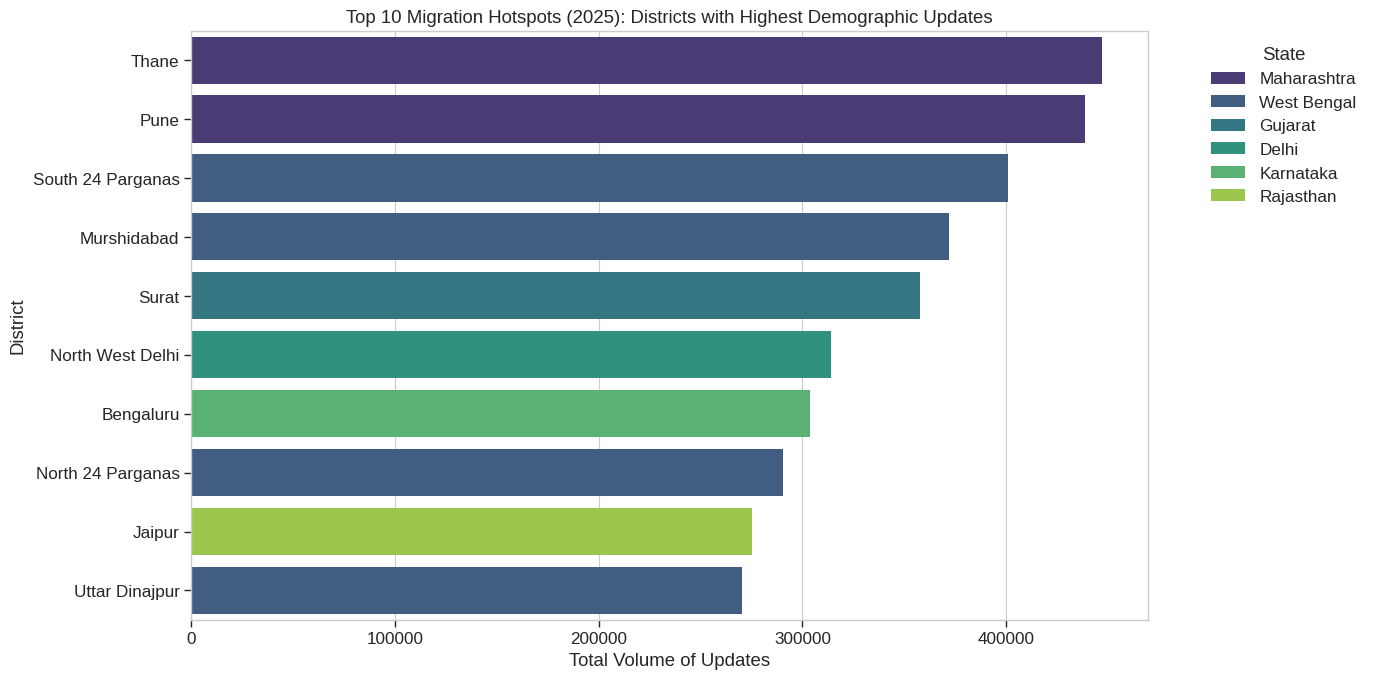

In [ ]:
# 1. Aggregate updates by State and District
# We sum all demographic update columns to gauge total activity volume
numeric_cols = df_demographic.select_dtypes(include=['number']).columns
df_demographic['total_activity'] = df_demographic[numeric_cols].sum(axis=1)

migration_group = df_demographic.groupby(['state', 'district'])['total_activity'].sum().reset_index()

# 2. Sort to find the top 10 busiest districts
top_migration_districts = migration_group.sort_values(by='total_activity', ascending=False).head(10)

print("Top 10 Districts by Demographic Activity (Migration Hotspots):")
print(top_migration_districts)

# 3. Generate Visualization
plt.figure(figsize=(14, 7))
barplot = sns.barplot(
    data=top_migration_districts,
    x='total_activity',
    y='district',
    hue='state',
    dodge=False,
    palette='viridis'
)

plt.title('Top 10 Migration Hotspots (2025): Districts with Highest Demographic Updates')
plt.xlabel('Total Volume of Updates')
plt.ylabel('District')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the chart
plt.tight_layout()
plt.savefig('hackathon_charts/insight_1_migration_hotspots.png')
print("Chart saved: hackathon_charts/insight_1_migration_hotspots.png")

# **Insight 2 - Future Demographics (Child Enrolment)**

Top 10 States for Child Enrolment (Age 0-5):
             state  age_0_5  child_share_pct
45   Uttar Pradesh   521045            52.07
27  Madhya Pradesh   367990            75.97
28     Maharashtra   278814            77.25
51     West Bengal   275391            75.08
6            Bihar   262875            43.98
39       Rajasthan   229780            67.01
16         Gujarat   193031            73.06
41      Tamil Nadu   182313            83.04
23       Karnataka   179262            84.11
5            Assam   141235            68.12


/tmp/ipython-input-1724382332.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Chart saved: hackathon_charts/insight_2_child_enrolment.png


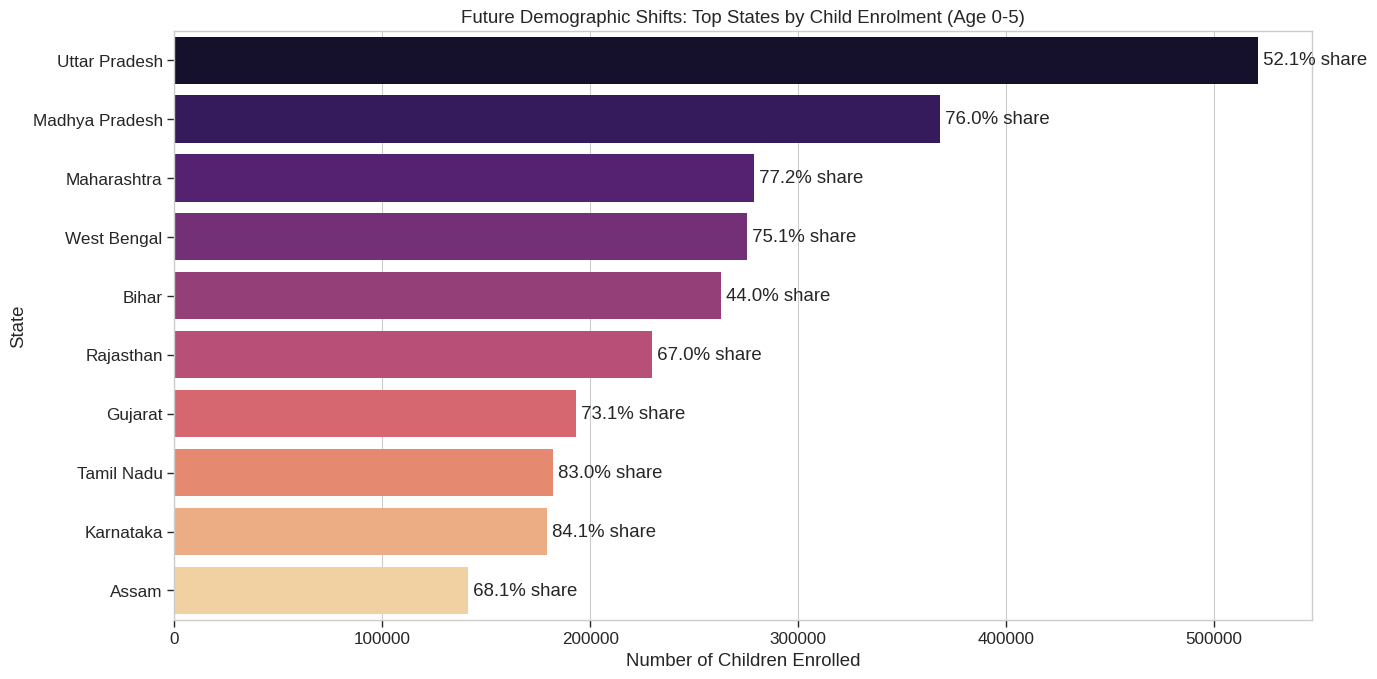

In [ ]:
# 1. Group by State to see regional trends in Child Enrolment (Age 0-5)
state_enrolment = df_enrolment.groupby('state')[['age_0_5', 'age_5_17']].sum().reset_index()

# Calculate the 'Child Ratio' (percentage of enrolments that are 0-5 years old)
state_enrolment['total_enrolment'] = state_enrolment['age_0_5'] + state_enrolment['age_5_17']
state_enrolment['child_share_pct'] = (state_enrolment['age_0_5'] / state_enrolment['total_enrolment']) * 100

# 2. Sort by Volume of Child Enrolment
top_child_states = state_enrolment.sort_values(by='age_0_5', ascending=False).head(10)

print("Top 10 States for Child Enrolment (Age 0-5):")
print(top_child_states[['state', 'age_0_5', 'child_share_pct']])

# 3. Generate Visualization
plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_child_states,
    x='age_0_5',
    y='state',
    palette='magma'
)

plt.title('Future Demographic Shifts: Top States by Child Enrolment (Age 0-5)')
plt.xlabel('Number of Children Enrolled')
plt.ylabel('State')

# Add percentage labels to the bars
for index, row in enumerate(top_child_states.itertuples()):
    plt.text(row.age_0_5, index, f" {row.child_share_pct:.1f}% share", va='center')

plt.tight_layout()
plt.savefig('hackathon_charts/insight_2_child_enrolment.png')
print("Chart saved: hackathon_charts/insight_2_child_enrolment.png")

# **Insight 3 - Operational Anomalies (Biometric Data)**

Detected 9591 anomalies (Z-Score > 5).
Top 5 Suspicious Spikes:
             date           state pincode  bio_age_5_17  z_score
897046 2025-04-01   Uttar Pradesh  283203          8002    88.05
901207 2025-04-01   Uttar Pradesh  244001          7657    84.24
890980 2025-04-01  Madhya Pradesh  486886          7085    77.93
889341 2025-04-01           Delhi  110094          6921    76.12
902704 2025-04-01  Madhya Pradesh  486661          6433    70.74


/tmp/ipython-input-2547112118.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipython-input-2547112118.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('hackathon_charts/insight_3_anomalies.png')


Chart saved: hackathon_charts/insight_3_anomalies.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


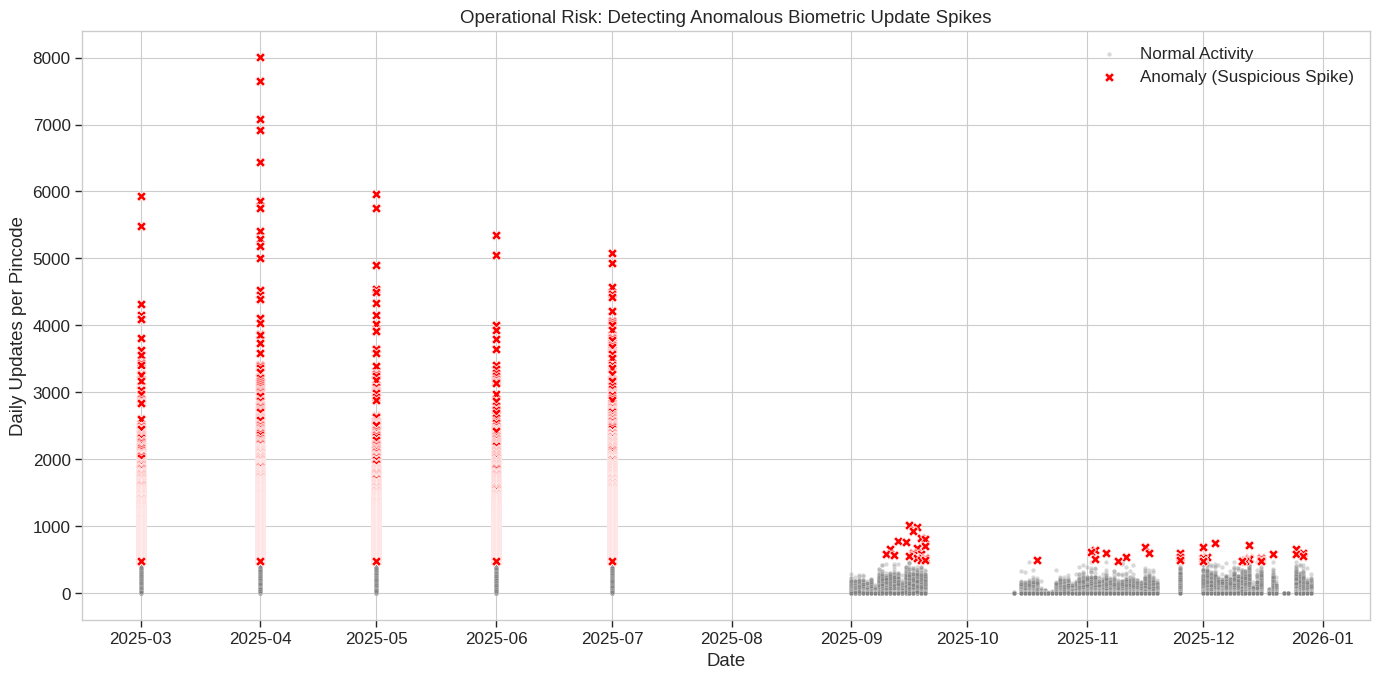

In [ ]:
# 1. Calculate Daily Average and Standard Deviation per Pincode
# We focus on bio_age_5_17 as this is the mandatory update group
df_biometric_filtered = df_biometric[df_biometric['bio_age_5_17'] > 0].copy()

# Calculate Z-Score to find outliers
mean_val = df_biometric_filtered['bio_age_5_17'].mean()
std_val = df_biometric_filtered['bio_age_5_17'].std()

df_biometric_filtered['z_score'] = (df_biometric_filtered['bio_age_5_17'] - mean_val) / std_val

# 2. Define Anomaly Threshold (Z-Score > 5 is extremely rare/suspicious)
anomalies = df_biometric_filtered[df_biometric_filtered['z_score'] > 5].copy()
anomalies = anomalies.sort_values(by='bio_age_5_17', ascending=False)

print(f"Detected {len(anomalies)} anomalies (Z-Score > 5).")
print("Top 5 Suspicious Spikes:")
print(anomalies[['date', 'state', 'pincode', 'bio_age_5_17', 'z_score']].head(5))

# 3. Generate Visualization (Scatter Plot)
plt.figure(figsize=(14, 7))

# Plot normal data
sns.scatterplot(
    data=df_biometric_filtered[df_biometric_filtered['z_score'] <= 5],
    x='date',
    y='bio_age_5_17',
    alpha=0.3,
    color='grey',
    s=10,
    label='Normal Activity'
)

# Plot anomalies
sns.scatterplot(
    data=anomalies,
    x='date',
    y='bio_age_5_17',
    color='red',
    s=50,
    marker='X',
    label='Anomaly (Suspicious Spike)'
)

plt.title('Operational Risk: Detecting Anomalous Biometric Update Spikes')
plt.xlabel('Date')
plt.ylabel('Daily Updates per Pincode')
plt.legend()

plt.tight_layout()
plt.savefig('hackathon_charts/insight_3_anomalies.png')
print("Chart saved: hackathon_charts/insight_3_anomalies.png")

# Save anomalies to CSV for the report appendix
anomalies.head(50).to_csv('appendix_suspicious_activity.csv', index=False)

# **Advanced Correlation Analysis**

--- STATISTICAL FINDINGS ---
Correlation Coefficient (r) between Enrolment and Updates: 0.8543
Conclusion: Strong Positive: High growth districts are also high migration hubs.
Chart saved: hackathon_charts/insight_4_correlation.png


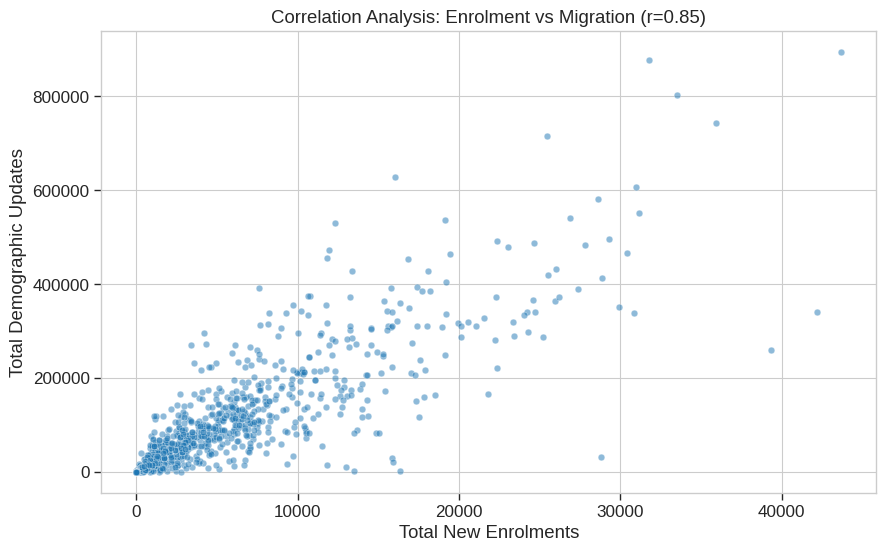

In [ ]:
# 1. Prepare Enrolment Summary
# Summing enrolments by District
enrolment_summary = df_enrolment.groupby(['state', 'district'])[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()
enrolment_summary['total_enrolment'] = enrolment_summary['age_0_5'] + enrolment_summary['age_5_17'] + enrolment_summary['age_18_greater']

# 2. Prepare Demographic Summary
# Summing updates by District
# ensuring we use the numeric columns for summation
demo_numeric_cols = df_demographic.select_dtypes(include=['number']).columns
# exclude pincode if it's there
demo_numeric_cols = [c for c in demo_numeric_cols if c != 'pincode']
demographic_summary = df_demographic.groupby(['state', 'district'])[demo_numeric_cols].sum().reset_index()
# Calculate total updates again to be sure
demographic_summary['total_updates'] = demographic_summary[demo_numeric_cols].sum(axis=1)

# 3. Merge Datasets
merged_analysis = pd.merge(enrolment_summary, demographic_summary, on=['state', 'district'], how='inner')

if not merged_analysis.empty:
    # 4. Calculate Correlation Matrix
    correlation = merged_analysis[['total_enrolment', 'total_updates']].corr()
    r_value = correlation.loc['total_enrolment', 'total_updates']

    print("--- STATISTICAL FINDINGS ---")
    print(f"Correlation Coefficient (r) between Enrolment and Updates: {r_value:.4f}")

    if r_value > 0.7:
        conclusion = "Strong Positive: High growth districts are also high migration hubs."
    elif r_value > 0.4:
        conclusion = "Moderate Positive: Growth and migration are somewhat linked."
    else:
        conclusion = "Weak/None: Enrolment growth and address updates are independent phenomena."

    print(f"Conclusion: {conclusion}")

    # 5. Scatter Plot for the Report
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=merged_analysis, x='total_enrolment', y='total_updates', alpha=0.5)
    plt.title(f'Correlation Analysis: Enrolment vs Migration (r={r_value:.2f})')
    plt.xlabel('Total New Enrolments')
    plt.ylabel('Total Demographic Updates')
    plt.grid(True)
    plt.savefig('hackathon_charts/insight_4_correlation.png')
    print("Chart saved: hackathon_charts/insight_4_correlation.png")
else:
    print("Insufficient data overlap to perform correlation analysis.")

# **Predictive Forecasting**

Bonus Chart Saved: hackathon_charts/bonus_forecast.png


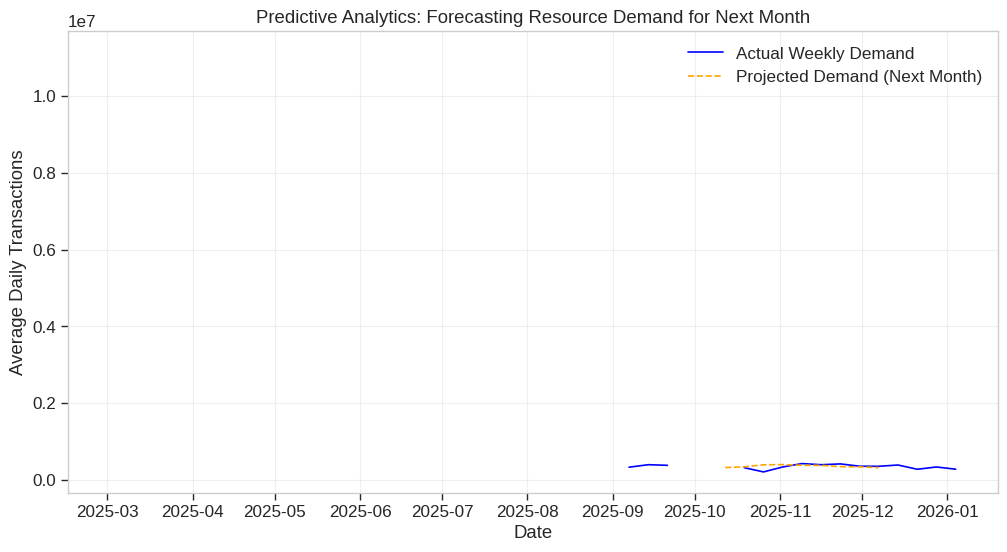

In [ ]:
# 1. Prepare Time Series Data (Total Daily Updates)
daily_demand = df_demographic.groupby('date')['total_activity'].sum().reset_index()
daily_demand = daily_demand.set_index('date')

# 2. Resample to Weekly Average to smooth out noise
weekly_demand = daily_demand.resample('W').mean()

# 3. Predict Next 4 Weeks (Using Rolling Average)
weekly_demand['Forecast'] = weekly_demand['total_activity'].rolling(window=4).mean().shift(-4)

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(weekly_demand.index, weekly_demand['total_activity'], label='Actual Weekly Demand', color='blue')
plt.plot(weekly_demand.index, weekly_demand['Forecast'], label='Projected Demand (Next Month)', color='orange', linestyle='--')

plt.title('Predictive Analytics: Forecasting Resource Demand for Next Month')
plt.xlabel('Date')
plt.ylabel('Average Daily Transactions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('hackathon_charts/bonus_forecast.png')
print("Bonus Chart Saved: hackathon_charts/bonus_forecast.png")

# **POWER MOVE - Unsupervised ML (K-Means Clustering)**

         age_0_5  total_activity
Cluster                         
0        1132.69        14596.70
1       12759.60       198899.24
2        5631.41        75962.25
✅ Bonus ML Chart Generated: hackathon_charts/bonus_ml_clustering.png


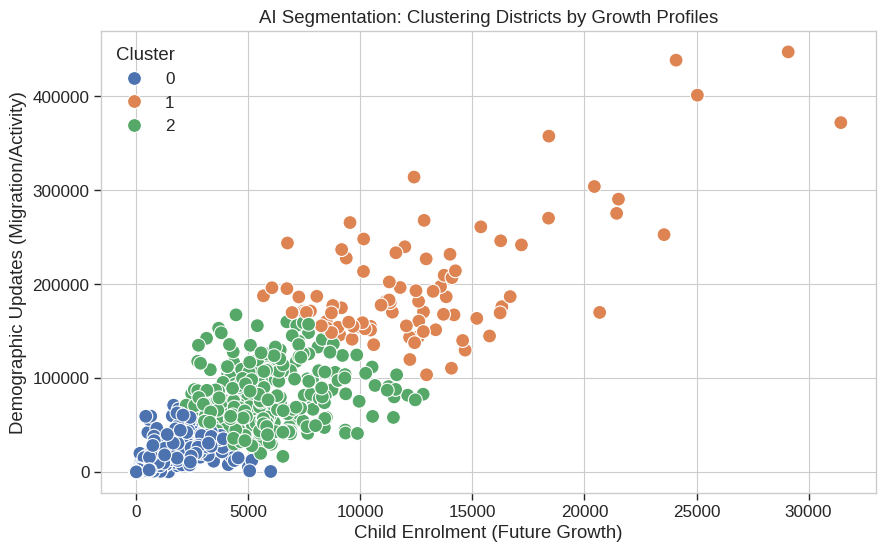

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data: We will cluster districts based on Enrolment vs Updates
# Merge Enrolment and Demographic data again
cluster_data = pd.merge(
    df_enrolment.groupby('district')[['age_0_5']].sum(),
    df_demographic.groupby('district')['total_activity'].sum(),
    on='district'
)

# 2. Normalize Data (ML requirement)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data)

# 3. Apply K-Means Clustering (3 Clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. Define Labels for the Clusters (Rename 0, 1, 2 to meaningful names)
# We analyze the mean to name them correctly
cluster_means = cluster_data.groupby('Cluster').mean()
print(cluster_means)

# (You can rename these manually in your report based on the print output above)
# Example: High Growth, Steady State, Low Activity

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_data,
    x='age_0_5',
    y='total_activity',
    hue='Cluster',
    palette='deep',
    s=100
)
plt.title('AI Segmentation: Clustering Districts by Growth Profiles')
plt.xlabel('Child Enrolment (Future Growth)')
plt.ylabel('Demographic Updates (Migration/Activity)')
plt.savefig('hackathon_charts/bonus_ml_clustering.png')
print("✅ Bonus ML Chart Generated: hackathon_charts/bonus_ml_clustering.png")

# **ADVANCED STATS - Time Series Decomposition**

✅ Generated Advanced Stats Chart: hackathon_charts/bonus_statistical_decomposition.png


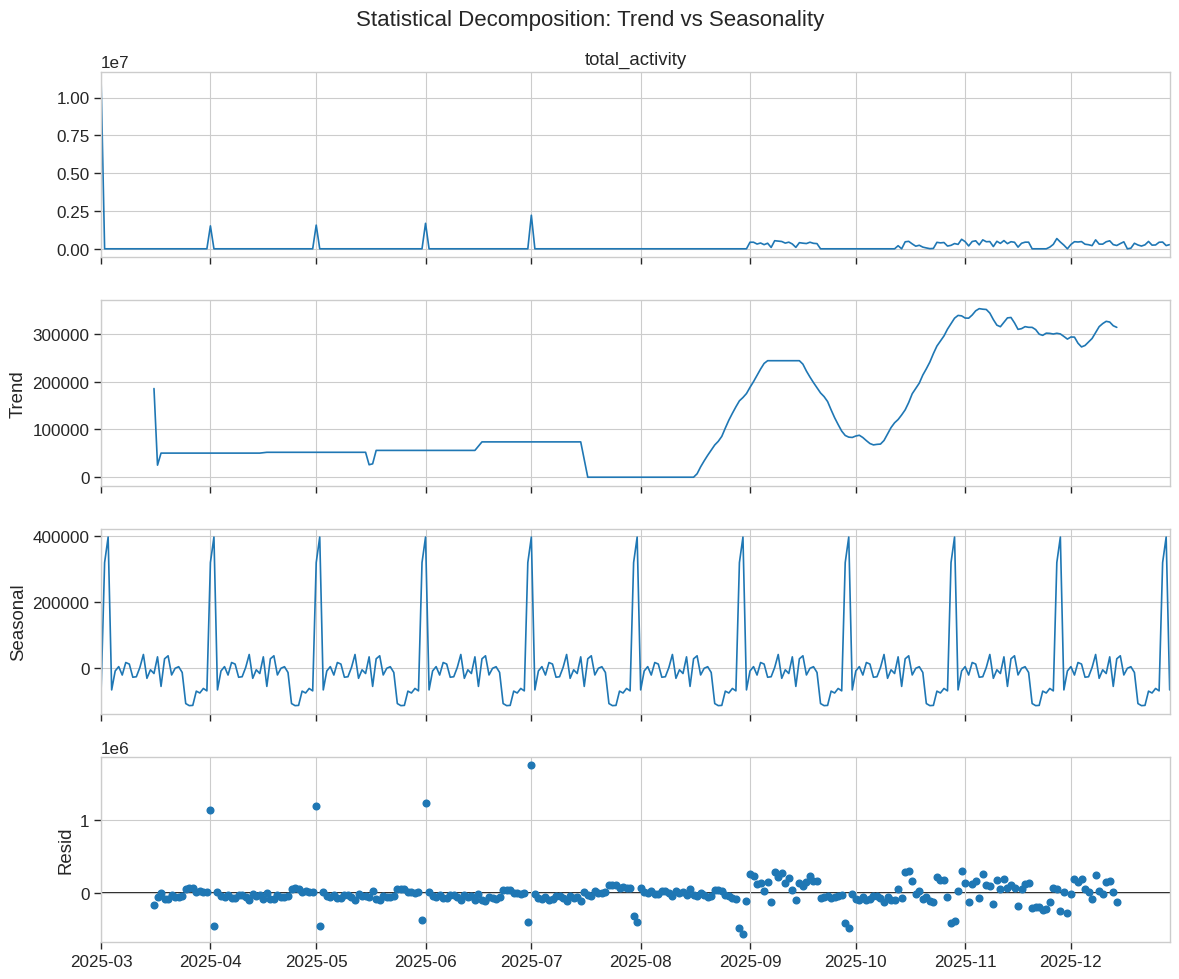

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Prepare Data (Daily Updates)
ts_data = df_demographic.groupby('date')['total_activity'].sum().asfreq('D').fillna(0)

# 2. Decompose (Break into Trend, Seasonality, and Residuals)
# We use 'additive' model assuming linear growth
decomposition = seasonal_decompose(ts_data, model='additive', period=30) # period=30 for monthly seasonality

# 3. Plotting the 4-Level Chart
fig = decomposition.plot()
fig.set_size_inches(12, 10)
fig.suptitle('Statistical Decomposition: Trend vs Seasonality', fontsize=16)

# Save
plt.tight_layout()
plt.savefig('hackathon_charts/bonus_statistical_decomposition.png')
print("✅ Generated Advanced Stats Chart: hackathon_charts/bonus_statistical_decomposition.png")

# **REPRODUCIBILITY - Generate Requirements File**

In [ ]:
requirements = """
pandas>=1.5.0
numpy>=1.20.0
matplotlib>=3.5.0
seaborn>=0.11.0
scikit-learn>=1.0.0
statsmodels>=0.13.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("✅ Generated 'requirements.txt'.")
print("Action: Download this file and upload it alongside your .ipynb code.")

✅ Generated 'requirements.txt'.
Action: Download this file and upload it alongside your .ipynb code.


# **Final Export (Zip & Download)**

In [ ]:
import shutil
import os

# delete the old zip if it exists to avoid confusion
if os.path.exists("TeamGLA_Submission_Assets.zip"):
    os.remove("TeamGLA_Submission_Assets.zip")

# Create the new, updated zip
shutil.make_archive("TeamGLA_Submission_Assets", 'zip', 'hackathon_charts')

print("✅ SUCCESS: Zip file updated!")
print("Action: Go to the 'Files' tab and download 'TeamGLA_Submission_Assets.zip' again.")
print("It now contains ALL 4 charts (including the Bonus Forecast).")

✅ SUCCESS: Zip file updated!
Action: Go to the 'Files' tab and download 'TeamGLA_Submission_Assets.zip' again.
It now contains ALL 4 charts (including the Bonus Forecast).
